In [1]:
import os

import chemiscope
import ipi
from ase.visualize import view
import nqetools as nqe
# This follows:
# https://atomistic-cookbook.org/examples/pi-metad/pi-metad.html

In [2]:
# Make a directory to store everything
directory_opti = "opti"
directory_md = "md"
directory_meta_md = "meta_md"
directory_meta_pimd = "meta_pimd"

n_beads = 8
timestep = 1.0  # fs
total_steps = 5000
total_steps_md = 100
stride = 10
temperature = 300
thermostat = 'smart_sampling_1ps_n6_w2'
md_type = "NVT-GLE"
driver_code = 'zundel'

# Plumed hills settings
n_bins = 100
stride_hills = 100
cv_limits = [[0.21, 0.31], [-1, 1]]

# Plumed settings
plumed_type_mtd = "mtd-coord"
plumed_args_mtd = {'sigma': [0.005, 0.05],
                   'bias': 10,
                   'height': 0.04, }

plumed_type_opes = "opes-coord"
plumed_args_opes = {'barrier': 0.08,
                    'stride_hills': stride_hills,
                    'explore': True, }

plumed_type_opes = "opes-coord"
plumed_args_opes = {'barrier': 0.2,
                    'stride_hills': stride_hills,
                    'explore': True, }


In [3]:
atoms = nqe.read_ipi_xyz("h5o2+.xyz")[-1]
atoms.center()
# view(atoms)

In [4]:
# Run minimization
output = nqe.run_optimise(directory_opti,
                          atoms,
                          driver=driver_code)
atoms_opti, output_data_opti, output_desc_opti = output

Running the minimisation with the driver: zundel

 ____       ____       ____       ____
/    \     /    \     /    \     /    \
|  #################################  |
\__#_/     \____/     \____/     \_#__/
   #    _        _______  _____    #
   #   (_)      |_   __ \|_   _|   #      -*-   v 3.1  -*-
   #   __  ______ | |__) | | |     #
   Y  [  ||______||  ___/  | |     #      A Universal Force Engine
  0 0  | |       _| |_    _| |_    #
   #  [___]     |_____|  |_____|   #
 __#_       ____       ____       _#__
/  # \     /    \     /    \     / #  \
|  #################################  |
\____/     \____/     \____/     \____/

    
 @system: Initializing system object 
 @simulation: Initializing simulation object 
@ RANDOM SEED: The seed used in this calculation was 1740943025050
 @init_file: Initializing from file init.xyz. Dimension: length, units: angstrom, cell_units: automatic
 @init_file: Initializing from file init.xyz. Dimension: length, units: automatic, cell_units: au

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


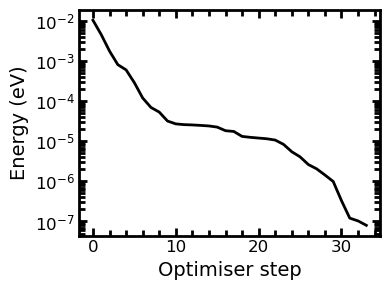

In [5]:
# Plot the energy of the minimisation
nqe.plot_step_energy(output_data_opti)

In [6]:
# Run unbiased MD
output = nqe.run_md(directory_md,
                    atoms_opti,
                    driver=driver_code,
                    total_steps=total_steps_md,
                    temperature=temperature,
                    timestep=timestep,
                    thermostat=thermostat,
                    md_type=md_type,
                    stride=stride,
                    n_beads=1)
atoms_md, output_data_md, output_desc_md = output

Running the MD (NVT-GLE) with the driver: zundel

 ____       ____       ____       ____
/    \     /    \     /    \     /    \
|  #################################  |
\__#_/     \____/     \____/     \_#__/
   #    _        _______  _____    #
   #   (_)      |_   __ \|_   _|   #      -*-   v 3.1  -*-
   #   __  ______ | |__) | | |     #
   Y  [  ||______||  ___/  | |     #      A Universal Force Engine
  0 0  | |       _| |_    _| |_    #
   #  [___]     |_____|  |_____|   #
 __#_       ____       ____       _#__
/  # \     /    \     /    \     / #  \
|  #################################  |
\____/     \____/     \____/     \____/

    
 @system: Initializing system object 
 @simulation: Initializing simulation object 
@ RANDOM SEED: The seed used in this calculation was 31415
 @init_file: Initializing from file init.xyz. Dimension: length, units: angstrom, cell_units: automatic
 @init_file: Initializing from file init.xyz. Dimension: length, units: automatic, cell_units: automatic


In [7]:
idx1 = 0
idx2 = 1
# Get a list of all the atom indexes
tmp = list(range(len(atoms)))
print(tmp)

# remove idx1 and idx2
tmp.remove(idx1)
tmp.remove(idx2)
print(tmp)

# add one to all the indexes
tmp = [x + 1 for x in tmp]
print(tmp)

group_b_str = ",".join([str(x) for x in tmp])
print(group_b_str)


[0, 1, 2, 3, 4, 5, 6]
[2, 3, 4, 5, 6]
[3, 4, 5, 6, 7]
3,4,5,6,7


/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


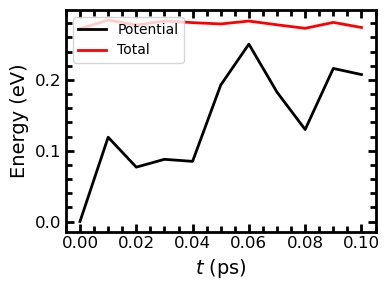

In [8]:
# Plot the energy conservation
nqe.plot_time_energy_conservation(output_data_md)

In [9]:
# Run metadynamics
output = nqe.run_plumed_md(directory_meta_md,
                           atoms_md,
                           driver=driver_code,
                           total_steps=total_steps,
                           temperature=temperature,
                           timestep=timestep,
                           thermostat=thermostat,
                           md_type=md_type,
                           stride=stride,
                           n_beads=1,
                           plumed_type=plumed_type_mtd,
                           plumed_args=plumed_args_mtd)
atoms_meta_md, output_data_meta_md, output_desc_meta_md = output

Running the MD (NVT-GLE) with the driver: zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

In [10]:
# colvar_data = ipi.read_trajectory(os.path.join(directory_meta_md, "md.colvar_0"), format="extras")[
#     "d,c1.lessthan,c2.lessthan,dc,mtd.bias"
# ]
# traj_data = ipi.read_trajectory(os.path.join(directory_meta_md, "md.pos_0.xyz"))
# # Chemiscope plot
# chemiscope.show(
#     frames=traj_data,
#     properties=dict(
#         d_OO=10 * colvar_data[:, 0],  # nm to Å
#         delta_coord=colvar_data[:, 1],
#         bias=27.211386 * output_data["ensemble_bias"],  # Ha to eV
#         time=2.4188843e-05 * output_data["time"],  # atomictime to ps
#     ),  # attime to ps
#     settings=chemiscope.quick_settings(
#         x="d_OO", y="delta_coord", z="bias", color="time", trajectory=True
#     ),
#     mode="default",
# )

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


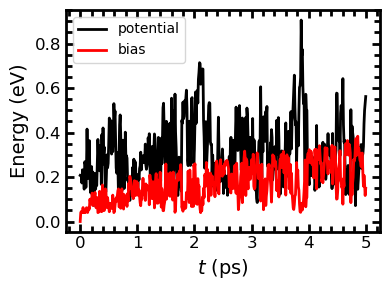

In [11]:
# Plot the time evolution of the energy and bias
nqe.plot_time_potential_bias(output_data_meta_md)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


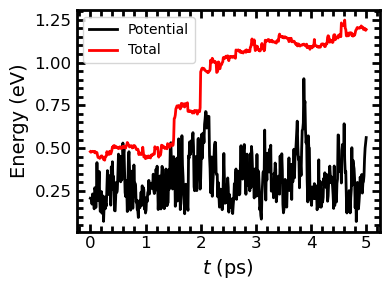

In [12]:
# Plot the energy conservation
nqe.plot_time_energy_conservation(output_data_meta_md)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


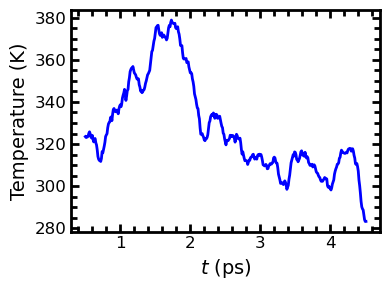

In [13]:
# Plot the time evolution of the temperature
nqe.plot_time_temperature(output_data_meta_md)

Running plumed hills
Running command:
plumed sum_hills --hills meta_md/HILLS --outfile meta_md/FES --stride 100 --kt 2.49 --mintozero --min 0.21,-1 --max 0.31,1 --bin 100,100
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:23:39
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/anaconda3/envs/ipi_env2/lib/plumed
PLUMED: For installed feature, see /home/louie/anaconda3/envs/ipi_env2/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: 
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 1
PLUMED: File suffix: 
PLUMED: Timestep: 0.000000
PLUMED: KbT has not been set by the MD engine
PLUMED: It should be set by hand where needed
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUM

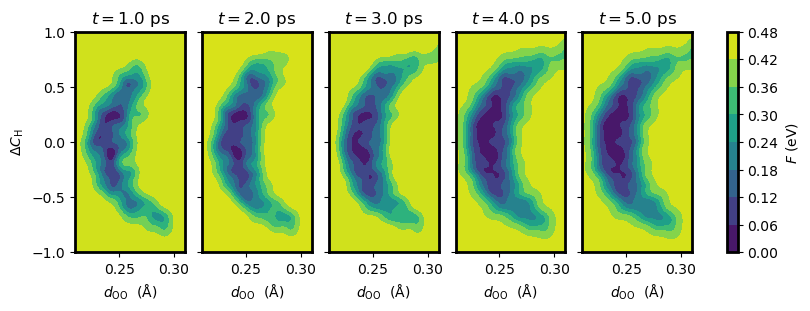

In [14]:
# Run the hills command
nqe.run_plumed_hills(directory_meta_md,
                     temperature=temperature,
                     bins=n_bins,
                     stride=stride_hills,
                     cv=cv_limits)
# Load the free energy surface data
fes_arrays_meta_md = nqe.load_fes_data(directory_meta_md, n_bins)
fes_times = nqe.get_fes_times(timestep, total_steps, fes_arrays_meta_md)
# Plot the free energy surface convergence
nqe.plot_fes_contourf_series(fes_arrays_meta_md, fes_times)

In [15]:
# Run PIMD metadynamics
output = nqe.run_plumed_md(directory_meta_pimd,
                           atoms_md,
                           driver=driver_code,
                           total_steps=total_steps,
                           temperature=temperature,
                           timestep=timestep,
                           thermostat=thermostat,
                           md_type=md_type,
                           stride=stride,
                           n_beads=n_beads,
                           plumed_type=plumed_type_mtd,
                           plumed_args=plumed_args_mtd)
atoms_meta_pimd, output_data_meta_pimd, output_desc_meta_pimd = output

Running the MD (NVT-GLE) with the driver: zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


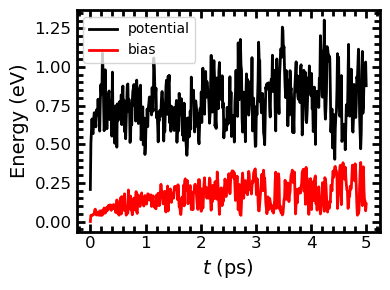

In [16]:
# Plot the time evolution of the energy and bias
nqe.plot_time_potential_bias(output_data_meta_pimd)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


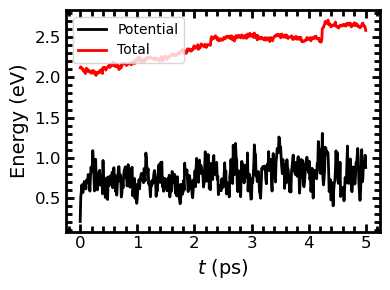

In [17]:
# Plot the energy conservation
nqe.plot_time_energy_conservation(output_data_meta_pimd)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


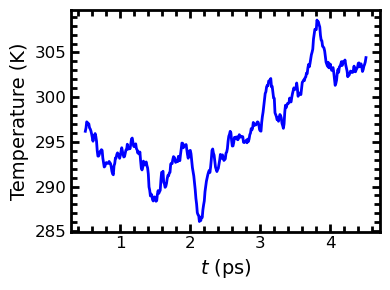

In [18]:
# Plot the time evolution of the temperature
nqe.plot_time_temperature(output_data_meta_pimd)

Running plumed hills
Running command:
plumed sum_hills --hills meta_pimd/HILLS --outfile meta_pimd/FES --stride 100 --kt 2.49 --mintozero --min 0.21,-1 --max 0.31,1 --bin 100,100
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:23:39
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/anaconda3/envs/ipi_env2/lib/plumed
PLUMED: For installed feature, see /home/louie/anaconda3/envs/ipi_env2/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: 
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 1
PLUMED: File suffix: 
PLUMED: Timestep: 0.000000
PLUMED: KbT has not been set by the MD engine
PLUMED: It should be set by hand where needed
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)


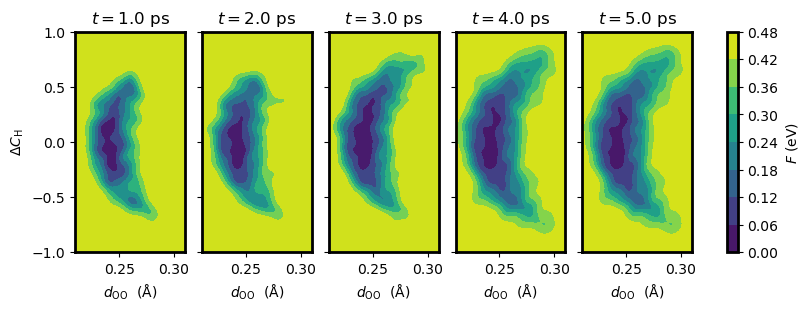

In [19]:
# Run the hills command
nqe.run_plumed_hills(directory_meta_pimd,
                     temperature=temperature,
                     bins=n_bins,
                     stride=stride_hills,
                     cv=cv_limits)
# Load the free energy surface data
fes_arrays_meta_pimd = nqe.load_fes_data(directory_meta_pimd, n_bins)
fes_times = nqe.get_fes_times(timestep, total_steps, fes_arrays_meta_pimd)
# Plot the free energy surface convergence
nqe.plot_fes_contourf_series(fes_arrays_meta_pimd, fes_times)

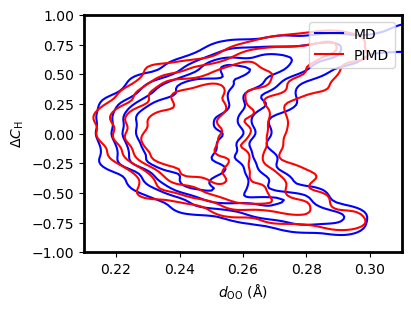

In [20]:
# Plot the comparison between MD and PIMD, compare the last frame
nqe.plot_fes_contour_compare(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])

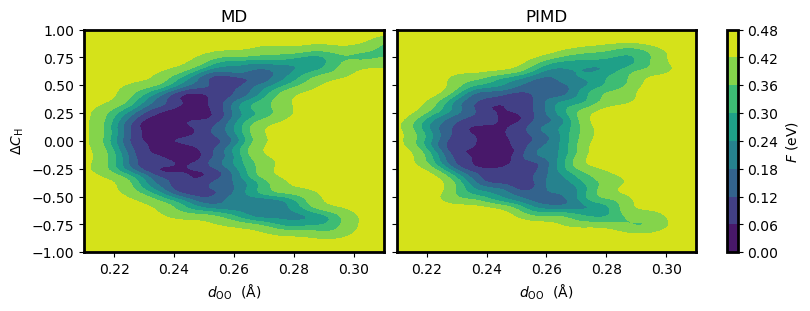

In [21]:
# Plot the comparison between MD and PIMD, compare the last frame
nqe.plot_fes_contourf_compare(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])

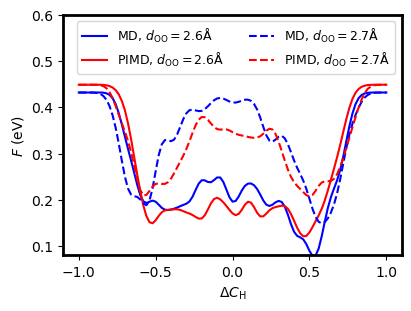

In [22]:
nqe.plot_fes_sep(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])

In [23]:
# Run OPES metadynamics
output = nqe.run_plumed_md(directory_meta_md,
                           atoms_md,
                           driver=driver_code,
                           total_steps=total_steps,
                           temperature=temperature,
                           timestep=timestep,
                           thermostat=thermostat,
                           md_type=md_type,
                           stride=stride,
                           n_beads=1,
                           plumed_type=plumed_type_opes,
                           plumed_args=plumed_args_opes)
atoms_meta_md, output_data_meta_md, output_desc_meta_md = output

Running the MD (NVT-GLE) with the driver: zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


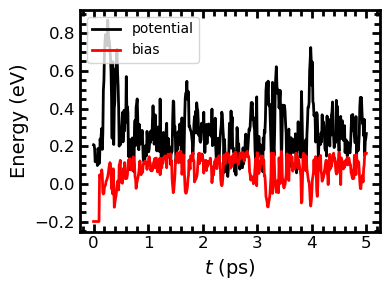

In [24]:
# Plot the time evolution of the energy and bias
nqe.plot_time_potential_bias(output_data_meta_md)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


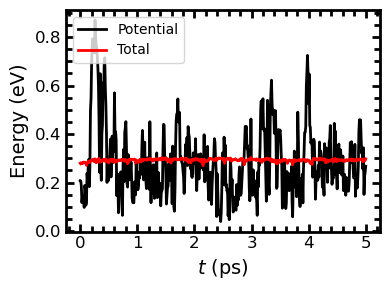

In [25]:
# Plot the energy conservation
nqe.plot_time_energy_conservation(output_data_meta_md)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


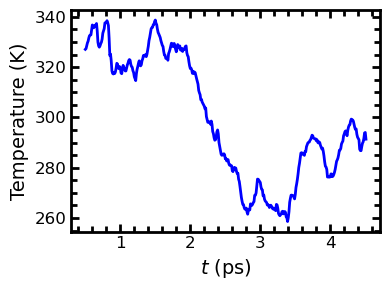

In [26]:
# Plot the time evolution of the temperature
nqe.plot_time_temperature(output_data_meta_md)

Running plumed OPES hills
Working directory: meta_md
Running command:
/home/louie/skunkworks/nqetools/nqetools/opes/fes_from_state.py --kt 2.49 --min 0.21,-1 --max 0.31,1 --bin 100,100 --all_stored
 a total of 5 stored states where found
  -> all will be printed
 building free energy from OPES_METAD_EXPLORE
Plumed OPES hills run complete

Loading meta_md/FES1.dat with 3 FIELDS
Loading meta_md/FES2.dat with 3 FIELDS
Loading meta_md/FES3.dat with 3 FIELDS
Loading meta_md/FES4.dat with 3 FIELDS
Loading meta_md/FES5.dat with 3 FIELDS


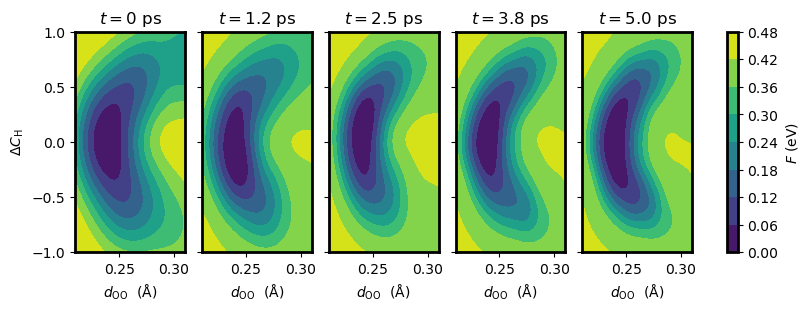

In [27]:
# Run the hills command
nqe.run_plumed_hills_opes(directory_meta_md,
                          temperature=temperature,
                          bins=n_bins,
                          cv=cv_limits)

fes_arrays_meta_md = nqe.load_fes_data(directory_meta_md, n_bins)
fes_times = nqe.get_fes_times(timestep, total_steps, fes_arrays_meta_md)
# Plot the free energy surface convergence
nqe.plot_fes_contourf_series(fes_arrays_meta_md, fes_times)

In [28]:
# Run PIMD OPES metadynamics
output = nqe.run_plumed_md(directory_meta_pimd,
                           atoms_md,
                           driver=driver_code,
                           total_steps=total_steps,
                           temperature=temperature,
                           timestep=timestep,
                           thermostat=thermostat,
                           md_type=md_type,
                           stride=stride,
                           n_beads=n_beads,
                           plumed_type=plumed_type_opes,
                           plumed_args=plumed_args_opes)
atoms_meta_pimd, output_data_meta_pimd, output_desc_meta_pimd = output

Running the MD (NVT-GLE) with the driver: zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


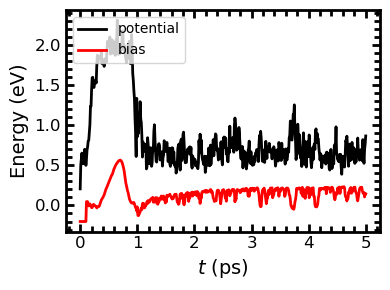

In [29]:
# Plot the time evolution of the energy and bias
nqe.plot_time_potential_bias(output_data_meta_pimd)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


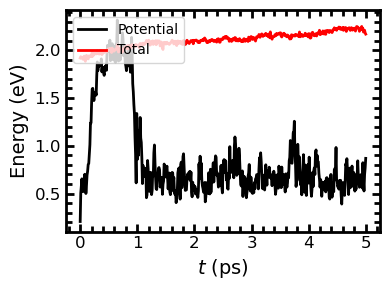

In [30]:
# Plot the energy conservation
nqe.plot_time_energy_conservation(output_data_meta_pimd)

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


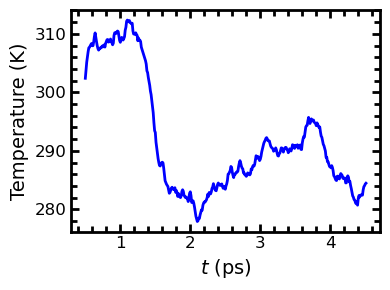

In [31]:
# Plot the time evolution of the temperature
nqe.plot_time_temperature(output_data_meta_pimd)

Running plumed OPES hills
Working directory: meta_pimd
Running command:
/home/louie/skunkworks/nqetools/nqetools/opes/fes_from_state.py --kt 2.49 --min 0.21,-1 --max 0.31,1 --bin 100,100 --all_stored
 a total of 5 stored states where found
  -> all will be printed
 building free energy from OPES_METAD_EXPLORE
Plumed OPES hills run complete

Loading meta_pimd/FES1.dat with 3 FIELDS
Loading meta_pimd/FES2.dat with 3 FIELDS
Loading meta_pimd/FES3.dat with 3 FIELDS
Loading meta_pimd/FES4.dat with 3 FIELDS
Loading meta_pimd/FES5.dat with 3 FIELDS


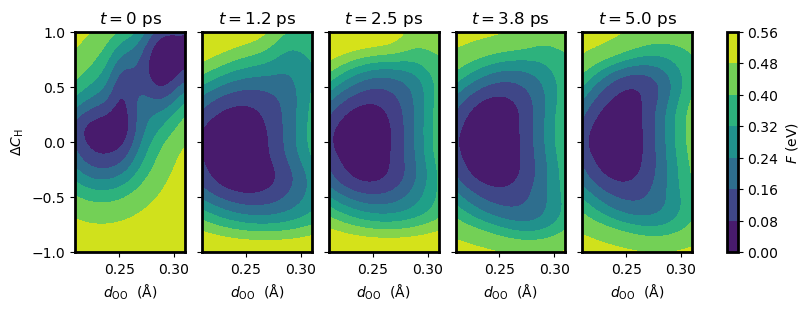

In [32]:
# Run the hills command
nqe.run_plumed_hills_opes(directory_meta_pimd,
                          temperature=temperature,
                          bins=n_bins,
                          cv=cv_limits)

fes_arrays_meta_pimd = nqe.load_fes_data(directory_meta_pimd, n_bins)
fes_times = nqe.get_fes_times(timestep, total_steps, fes_arrays_meta_pimd)
# Plot the free energy surface convergence
nqe.plot_fes_contourf_series(fes_arrays_meta_pimd, fes_times)

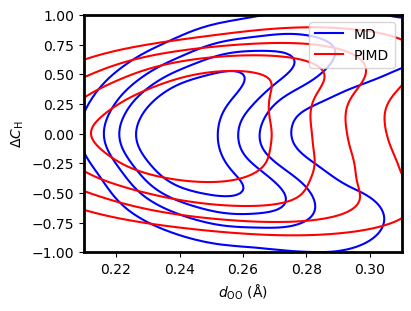

In [33]:
# Plot the comparison between MD and PIMD, compare the last frame
nqe.plot_fes_contour_compare(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])

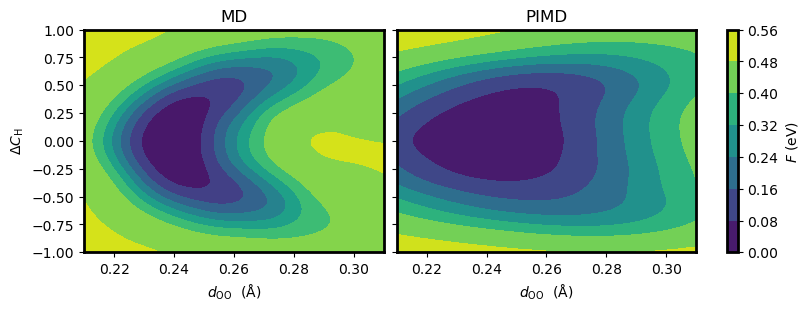

In [34]:
# Plot the comparison between MD and PIMD, compare the last frame
nqe.plot_fes_contourf_compare(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])

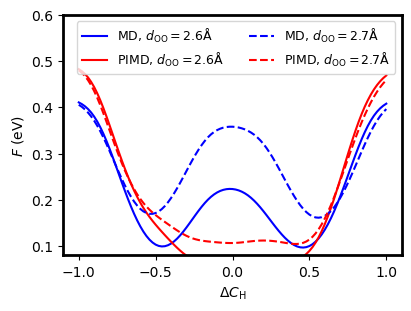

In [35]:
nqe.plot_fes_sep(fes_arrays_meta_md[-1], fes_arrays_meta_pimd[-1])